# Project submission

### Group number:
### Student IDs:
### Project name: Crypto Future Price Estimate for Market Making


## Table of contents

1. [Step 1: Business problem](#step-1-business-problem)
2. [Step 2: Machine learning problem](#step-2-machine-learning-problem)
3. [Step 3: Data exploration and preparation](#step-3-data-exploration-and-preparation)
4. [Step 4: Clustering the assets](#step-4-clustering-the-assets)
5. [Step 5: Feature engineering and target](#step-5-feature-engineering-and-target)
6. [Step 6: Chronological 70/20/10 split](#step-6-chronological-702010-split)
7. [Step 7: Feature importance by cluster](#step-7-feature-importance-by-cluster)
8. [Step 8: SHAP, PDP, ICE, and final feature selection](#step-8-shap-pdp-ice-and-final-feature-selection)
9. [Step 9: Asset-specific Ridge Regression](#step-9-asset-specific-ridge-regression)
10. [Step 10: Performance analysis](#step-10-performance-analysis)
11. [Step 11: Conclusion](#step-11-conclusion)


<a id="step-1-business-problem"></a>

## Step 1: What business problem are you solving?

As one of the most volatile assets, crypto assets pose a severe risk for any kind of firm involved in crypto trading activity, such as centralized exchanges like Coinbase or Binance, crypto asset management firms, or venture capitals like a16z, or traditional finance firms and financial services providers such as Revolut that allow users to trade assets.

In order to decrease inventory risk and also allow firms to take an informed stance on the future price of crypto assets, we want to create a simple model which, via a simple regression, allows the prediction of future asset prices. This would allow any business user to request a price prediction via a simple Excel spreadsheet or Python script. However, the difficulty lies in determining which features are actually important for the regression and which are just noise.

<a id="step-2-machine-learning-problem"></a>

## Step 2: What is the machine learning problem that you are solving?

The machine learning problem we are trying to solve is relatively simple. What we are trying to do is build a simple regression model, specifically a Ridge regression or L2 penalization model, to predict the future price. The actual difficulty lies not in performing the regression itself, but in finding which parameters are actually important.
Therefore, we start by clustering the assets into different groups so that we can find features that are important per class. 

After this, we develop trees of different depths to see which features actually hold, and develop SHAP values, ICE plots, and PDP plots to further analyze which features are important and which are just noise that can be neglected.
The actual difficulty here is to not overfit, but also to generalize well, while still making sure that the model is accurate and not too generalized

<a id="step-3-data-exploration-and-preparation"></a>

## Step 3: Data exploration and preparation

The code below follows the same style as the class notebooks: simple `pandas` checks, simple `matplotlib` / `seaborn` plots, and `sklearn` models.


In [1]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    davies_bouldin_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 160)
sns.set_theme(style="whitegrid")


Matplotlib is building the font cache; this may take a moment.


### Step 3.1: Load the data


In [2]:
df_raw = pd.read_csv("pr15_crypto.csv")

if "Unnamed: 0" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Unnamed: 0"])

df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])

print("Rows:", len(df_raw))
print("Columns:", df_raw.shape[1])
print("Assets:", df_raw["Asset_Name"].nunique())
print("Date range:", df_raw["timestamp"].min(), "to", df_raw["timestamp"].max())

display(df_raw.head())


Rows: 104324
Columns: 11
Assets: 14
Date range: 2018-01-01 00:00:00 to 2021-09-20 20:00:00


,Asset_ID,timestamp,Count,Open,High,Low,Close,Volume,VWAP,Weight,Asset_Name
0,0,2018-01-01 00:00:00,3272.0,8.5300,8.5300,8.1305,8.3401,136150.46,8.327702,4.304065,Binance Coin
1,0,2018-01-01 04:00:00,3231.0,8.3612,8.7000,8.3410,8.3600,100304.70,8.485586,4.304065,Binance Coin
2,0,2018-01-01 08:00:00,3412.0,8.3852,8.5300,8.0703,8.1604,113605.91,8.274129,4.304065,Binance Coin
3,0,2018-01-01 12:00:00,3678.0,8.1800,8.3300,7.8000,8.1101,156761.84,8.063121,4.304065,Binance Coin
4,0,2018-01-01 16:00:00,2030.0,8.1160,8.1778,7.9592,8.1150,61915.82,8.063309,4.304065,Binance Coin


In [3]:
checks = pd.DataFrame(
    {
        "value": [
            len(df_raw),
            df_raw.duplicated().sum(),
            df_raw.isna().sum().sum(),
            np.isinf(df_raw.select_dtypes(include="number")).sum().sum(),
        ]
    },
    index=["rows", "duplicate_rows", "missing_values", "infinite_values"],
)

asset_summary = (
    df_raw.groupby("Asset_Name")
    .agg(rows=("Close", "size"), min_close=("Close", "min"), max_close=("Close", "max"))
    .sort_values("rows", ascending=False)
)

display(checks)
display(asset_summary)


,value
rows,104324
duplicate_rows,0
missing_values,0
infinite_values,6


,rows,min_close,max_close
Asset_Name,,,
Bitcoin,8154,3165.973333,64530.898571
Bitcoin Cash,8154,74.460000,2856.856667
EOS.IO,8154,1.663300,22.504250
Ethereum,8154,82.298250,4334.685714
Ethereum Classic,8154,3.407050,148.242700
Litecoin,8154,22.850750,409.043000
Monero,8152,30.225000,515.620000
Binance Coin,8140,4.316300,683.385000
TRON,7933,0.008507,0.174305


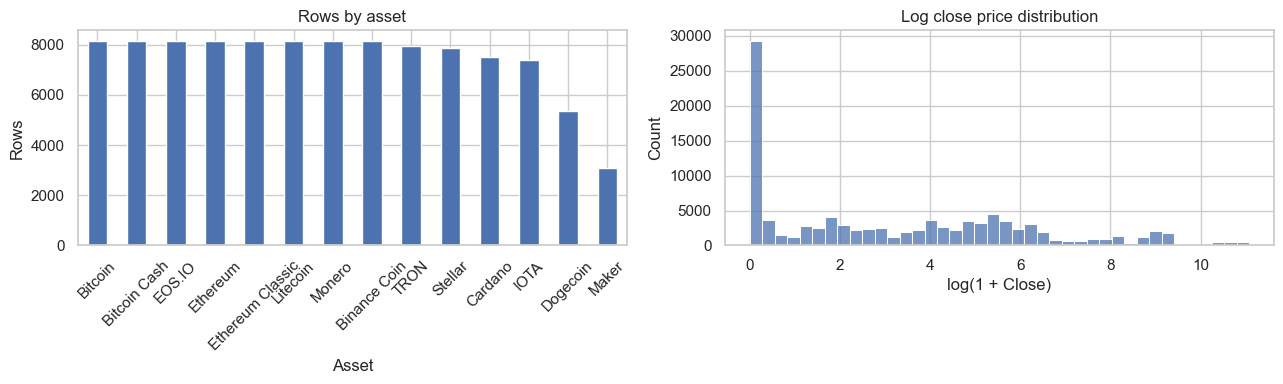

In [4]:
close_for_plot = pd.to_numeric(df_raw["Close"], errors="coerce")
close_for_plot = close_for_plot.replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_raw["Asset_Name"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Rows by asset")
axes[0].set_xlabel("Asset")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=45)

sns.histplot(np.log1p(close_for_plot), bins=40, ax=axes[1])
axes[1].set_title("Log close price distribution")
axes[1].set_xlabel("log(1 + Close)")

plt.tight_layout()
plt.show()


<a id="step-4-clustering-the-assets"></a>

## Step 4: Clustering the assets

We first cluster the assets using only the earlier part of the data. This keeps the clustering step separate from the final test period.
KMeans is the main clustering method because it is simple and was used in the class notebooks. We also compare it with Agglomerative Clustering and DBSCAN.


In [5]:
cluster_cutoff = df_raw["timestamp"].quantile(0.70)

df_cluster = df_raw[df_raw["timestamp"] <= cluster_cutoff].sort_values(
    ["Asset_ID", "timestamp"]
).copy()

numeric_cols = df_cluster.select_dtypes(include="number").columns
df_cluster[numeric_cols] = df_cluster[numeric_cols].replace([np.inf, -np.inf], np.nan)
df_cluster = df_cluster.dropna(subset=["Close", "Volume", "VWAP", "Count"])

cluster_group = df_cluster.groupby("Asset_ID", group_keys=False)
df_cluster["return_4h"] = cluster_group["Close"].pct_change()

asset_cluster_features = (
    df_cluster.groupby(["Asset_ID", "Asset_Name"])
    .agg(
        mean_close=("Close", "mean"),
        mean_volume=("Volume", "mean"),
        mean_count=("Count", "mean"),
        mean_return_4h=("return_4h", "mean"),
        volatility_4h=("return_4h", "std"),
    )
    .reset_index()
)

asset_cluster_features["log_mean_close"] = np.log1p(asset_cluster_features["mean_close"])
asset_cluster_features["log_mean_volume"] = np.log1p(asset_cluster_features["mean_volume"])
asset_cluster_features["log_mean_count"] = np.log1p(asset_cluster_features["mean_count"])

cluster_features = [
    "log_mean_close",
    "log_mean_volume",
    "log_mean_count",
    "mean_return_4h",
    "volatility_4h",
]

asset_cluster_features = asset_cluster_features.dropna(subset=cluster_features)

print("Clustering data ends at:", cluster_cutoff)
display(asset_cluster_features[["Asset_Name"] + cluster_features])


Clustering data ends at: 2020-09-13 08:00:00


,Asset_Name,log_mean_close,log_mean_volume,log_mean_count,mean_return_4h,volatility_4h
0,Binance Coin,2.842460,12.899740,9.358667,0.000487,0.023543
1,Bitcoin,8.970966,9.957915,11.899587,0.000086,0.016173
2,Bitcoin Cash,6.185258,10.673766,10.063616,-0.000083,0.024990
3,Cardano,0.078444,17.861483,9.465949,0.000047,0.021719
4,Dogecoin,0.002624,18.419416,7.619103,0.000165,0.018414
5,EOS.IO,1.816057,15.354811,10.561959,0.000143,0.025098
6,Ethereum,5.728074,12.363909,11.266628,0.000098,0.020621
7,Ethereum Classic,2.387977,13.312525,9.515300,-0.000020,0.023738
8,IOTA,0.344924,14.405952,7.997145,-0.000165,0.022147
9,Litecoin,4.367147,12.223703,10.178603,-0.000021,0.021591


,k,inertia,silhouette,davies_bouldin
0,2,36.993,0.585,0.261
1,3,18.413,0.339,0.672
2,4,12.174,0.255,0.790
3,5,9.229,0.237,0.672
4,6,6.582,0.228,0.608


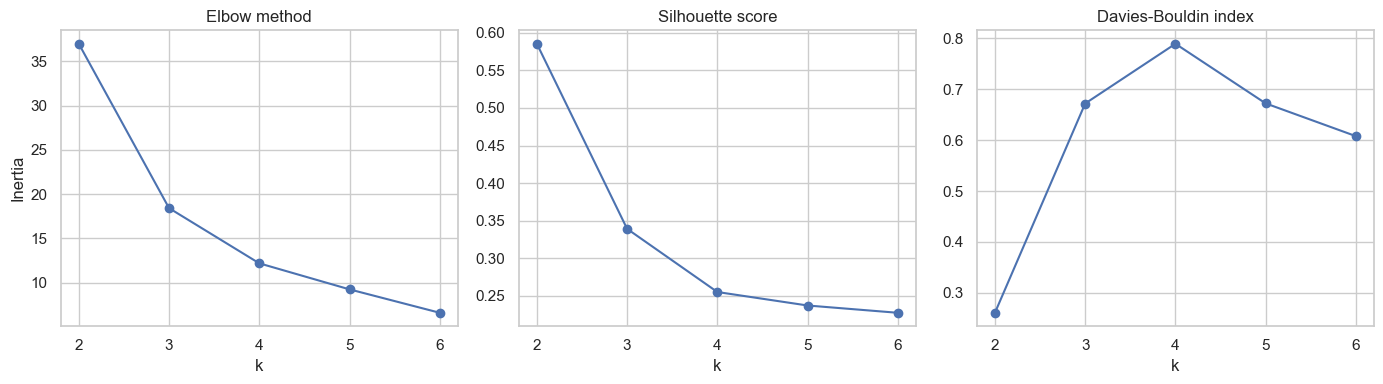

In [6]:
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(asset_cluster_features[cluster_features])

k_values = range(2, 7)
cluster_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = kmeans.fit_predict(X_cluster)
    cluster_scores.append(
        {
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette": silhouette_score(X_cluster, labels),
            "davies_bouldin": davies_bouldin_score(X_cluster, labels),
        }
    )

cluster_scores = pd.DataFrame(cluster_scores)
display(cluster_scores.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(cluster_scores["k"], cluster_scores["inertia"], marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(cluster_scores["k"], cluster_scores["silhouette"], marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")

axes[2].plot(cluster_scores["k"], cluster_scores["davies_bouldin"], marker="o")
axes[2].set_title("Davies-Bouldin index")
axes[2].set_xlabel("k")

plt.tight_layout()
plt.show()


In [7]:
chosen_k = 3

clustering_models = {
    "KMeans": KMeans(n_clusters=chosen_k, random_state=SEED, n_init=20),
    "Agglomerative": AgglomerativeClustering(n_clusters=chosen_k),
    "DBSCAN": DBSCAN(eps=1.5, min_samples=2),
}

method_rows = []

for name, model in clustering_models.items():
    labels = model.fit_predict(X_cluster)
    valid = labels != -1
    n_clusters = len(set(labels[valid]))
    n_noise = int((labels == -1).sum())

    if n_clusters > 1 and valid.sum() > n_clusters:
        sil = silhouette_score(X_cluster[valid], labels[valid])
        db = davies_bouldin_score(X_cluster[valid], labels[valid])
    else:
        sil = np.nan
        db = np.nan

    asset_cluster_features[name + "_cluster"] = labels
    method_rows.append(
        {
            "method": name,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette": sil,
            "davies_bouldin": db,
        }
    )

clustering_comparison = pd.DataFrame(method_rows)
asset_cluster_features["asset_cluster"] = asset_cluster_features["KMeans_cluster"]

display(clustering_comparison.round(3))
display(asset_cluster_features[["Asset_ID", "Asset_Name", "asset_cluster"]].sort_values(["asset_cluster", "Asset_Name"]))


,method,clusters,noise_points,silhouette,davies_bouldin
0,KMeans,3,0,0.339,0.672
1,Agglomerative,3,0,0.331,0.641
2,DBSCAN,1,3,NaN,NaN


,Asset_ID,Asset_Name,asset_cluster
10,10,Maker,0
0,0,Binance Coin,1
3,3,Cardano,1
4,4,Dogecoin,1
5,5,EOS.IO,1
7,7,Ethereum Classic,1
8,8,IOTA,1
12,12,Stellar,1
13,13,TRON,1
1,1,Bitcoin,2


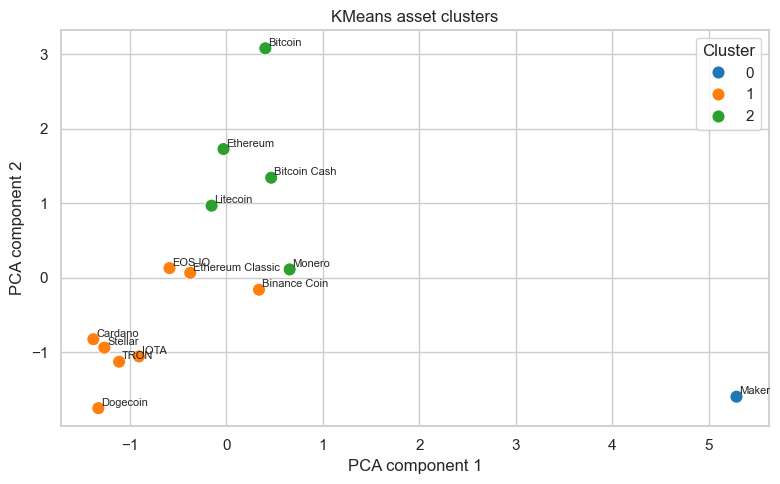

In [8]:
pca = PCA(n_components=2, random_state=SEED)
pca_values = pca.fit_transform(X_cluster)

asset_cluster_features["pca_1"] = pca_values[:, 0]
asset_cluster_features["pca_2"] = pca_values[:, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=asset_cluster_features,
    x="pca_1",
    y="pca_2",
    hue="asset_cluster",
    palette="tab10",
    s=90,
)

for _, row in asset_cluster_features.iterrows():
    plt.text(row["pca_1"] + 0.03, row["pca_2"] + 0.03, row["Asset_Name"], fontsize=8)

plt.title("KMeans asset clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


<a id="step-5-feature-engineering-and-target"></a>

## Step 5: Feature engineering and target

The target is a future price estimate one 4-hour step ahead. The realized future price is only used as `y` during training and evaluation. It is not included as an input feature.

The feature set stays small: current market prices, volume, short-term returns, volatility, simple calendar variables, the asset cluster, and cross-asset return variables.


In [9]:
df = df_raw.sort_values(["Asset_ID", "timestamp"]).copy()

numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Open", "High", "Low", "Close", "Volume", "VWAP", "Count"])

df = df.merge(
    asset_cluster_features[["Asset_ID", "asset_cluster"]],
    on="Asset_ID",
    how="left",
)

asset_group = df.groupby("Asset_ID", group_keys=False)

forecast_horizon_steps = 1
df["future_price"] = asset_group["Close"].shift(-forecast_horizon_steps)

df["candle_return"] = df["Close"] / df["Open"] - 1
df["high_low_range_pct"] = (df["High"] - df["Low"]) / df["Open"]
df["close_vwap_gap_pct"] = (df["Close"] - df["VWAP"]) / df["VWAP"]
df["volume_log"] = np.log1p(df["Volume"])
df["count_log"] = np.log1p(df["Count"])

df["return_4h"] = asset_group["Close"].pct_change(1)
df["return_8h"] = asset_group["Close"].pct_change(2)
df["return_24h"] = asset_group["Close"].pct_change(6)
df["rolling_return_mean_24h"] = asset_group["return_4h"].transform(
    lambda s: s.rolling(window=6, min_periods=3).mean()
)
df["rolling_volatility_24h"] = asset_group["return_4h"].transform(
    lambda s: s.rolling(window=6, min_periods=3).std()
)

by_time = df.groupby("timestamp")
df["assets_at_timestamp"] = by_time["return_4h"].transform("count")
df["market_return_4h"] = by_time["return_4h"].transform("mean")
df["other_assets_return_4h"] = (
    df["market_return_4h"] * df["assets_at_timestamp"] - df["return_4h"]
) / (df["assets_at_timestamp"] - 1)

returns_by_asset = df.pivot_table(index="timestamp", columns="Asset_Name", values="return_4h")
df["bitcoin_return_4h"] = df["timestamp"].map(returns_by_asset["Bitcoin"])
df["ethereum_return_4h"] = df["timestamp"].map(returns_by_asset["Ethereum"])

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month

candidate_features = [
    "asset_cluster",
    "Count",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "VWAP",
    "Weight",
    "candle_return",
    "high_low_range_pct",
    "close_vwap_gap_pct",
    "volume_log",
    "count_log",
    "return_4h",
    "return_8h",
    "return_24h",
    "rolling_return_mean_24h",
    "rolling_volatility_24h",
    "market_return_4h",
    "other_assets_return_4h",
    "bitcoin_return_4h",
    "ethereum_return_4h",
    "hour",
    "day_of_week",
    "month",
]

df_model = df.dropna(subset=candidate_features + ["future_price"]).copy()
df_model = df_model.sort_values(["timestamp", "Asset_ID"]).reset_index(drop=True)

print("Model rows:", len(df_model))
print("Candidate features:", len(candidate_features))
display(df_model[["timestamp", "Asset_Name", "Close", "future_price"] + candidate_features[:8]].head())


Model rows: 104220
Candidate features: 26


,timestamp,Asset_Name,Close,future_price,asset_cluster,Count,Open,High,Low,Close,Volume,VWAP
0,2018-01-02,Binance Coin,8.3986,8.3100,1,5852.0,8.450000,8.6599,8.340,8.3986,245387.240000,8.491222
1,2018-01-02,Bitcoin,13361.3440,13433.4000,2,101478.0,13427.492000,13999.0000,13200.000,13361.3440,17001.646278,13620.253646
2,2018-01-02,Bitcoin Cash,2375.5100,2340.9150,2,25712.0,2320.886667,2449.5000,2301.670,2375.5100,10974.484639,2386.746293
3,2018-01-02,EOS.IO,8.2216,8.1889,1,6014.0,7.640100,8.6000,7.622,8.2216,912278.064362,8.289561
4,2018-01-02,Ethereum,824.3900,850.0625,2,118792.0,756.225000,899.5000,749.060,824.3900,308228.416759,831.731032


<a id="step-6-chronological-702010-split"></a>

## Step 6: Chronological 70/20/10 split

The requested proportions are 70% train, 20% test, and 10% validation.
To avoid leakage, the chronological order is train → validation → final test, so the most recent 20% stays untouched until final evaluation.


In [10]:
unique_times = np.array(sorted(df_model["timestamp"].unique()))
n_times = len(unique_times)

train_end_time = unique_times[int(0.70 * n_times) - 1]
validation_end_time = unique_times[int(0.80 * n_times) - 1]

train_df = df_model[df_model["timestamp"] <= train_end_time].copy()
validation_df = df_model[
    (df_model["timestamp"] > train_end_time)
    & (df_model["timestamp"] <= validation_end_time)
].copy()
test_df = df_model[df_model["timestamp"] > validation_end_time].copy()

split_summary = pd.DataFrame(
    {
        "rows": [len(train_df), len(test_df), len(validation_df)],
        "share": [
            len(train_df) / len(df_model),
            len(test_df) / len(df_model),
            len(validation_df) / len(df_model),
        ],
        "start": [
            train_df["timestamp"].min(),
            test_df["timestamp"].min(),
            validation_df["timestamp"].min(),
        ],
        "end": [
            train_df["timestamp"].max(),
            test_df["timestamp"].max(),
            validation_df["timestamp"].max(),
        ],
    },
    index=["train", "test", "validation"],
)

display(split_summary)


,rows,share,start,end
train,69990,0.67156,2018-01-02 00:00:00,2020-08-09 04:00:00
test,22820,0.21896,2020-12-23 04:00:00,2021-09-20 16:00:00
validation,11410,0.10948,2020-08-09 08:00:00,2020-12-23 00:00:00


<a id="step-7-feature-importance-by-cluster"></a>

## Step 7: Feature importance by cluster

We use decision trees with different depths to see which features consistently matter inside each cluster.
This is not the final model. It is a simple feature-selection step before Ridge Regression.


In [11]:
tree_depths = [2, 4, 6]
tree_score_rows = []
tree_importance_rows = []

for cluster_id in sorted(train_df["asset_cluster"].unique()):
    cluster_train = train_df[train_df["asset_cluster"] == cluster_id]
    cluster_val = validation_df[validation_df["asset_cluster"] == cluster_id]

    X_train_cluster = cluster_train[candidate_features]
    y_train_cluster = cluster_train["future_price"]

    for depth in tree_depths:
        tree = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=100,
            random_state=SEED,
        )
        tree.fit(X_train_cluster, y_train_cluster)

        y_val_pred = tree.predict(cluster_val[candidate_features])

        tree_score_rows.append(
            {
                "cluster": cluster_id,
                "max_depth": depth,
                "validation_MAE": mean_absolute_error(cluster_val["future_price"], y_val_pred),
                "validation_RMSE": np.sqrt(mean_squared_error(cluster_val["future_price"], y_val_pred)),
                "validation_R2": r2_score(cluster_val["future_price"], y_val_pred),
            }
        )

        for feature, importance in zip(candidate_features, tree.feature_importances_):
            tree_importance_rows.append(
                {
                    "cluster": cluster_id,
                    "max_depth": depth,
                    "feature": feature,
                    "importance": importance,
                }
            )

tree_scores = pd.DataFrame(tree_score_rows)
tree_importance = (
    pd.DataFrame(tree_importance_rows)
    .groupby(["cluster", "feature"], as_index=False)["importance"]
    .mean()
    .sort_values(["cluster", "importance"], ascending=[True, False])
)

display(tree_scores.round(4))
display(tree_importance.groupby("cluster").head(8))


,cluster,max_depth,validation_MAE,validation_RMSE,validation_R2
0,0,2,32.7277,38.6451,0.6094
1,0,4,22.4793,29.3681,0.7744
2,0,6,22.4793,29.3681,0.7744
3,1,2,0.8097,1.4722,0.9727
4,1,4,0.2328,0.4969,0.9969
5,1,6,0.1017,0.2519,0.9992
6,2,2,899.2031,2428.5903,0.8211
7,2,4,394.4131,1266.6895,0.9513
8,2,6,335.7029,1257.8145,0.9520


,cluster,feature,importance
3,0,Low,0.708058
0,0,Close,0.272450
5,0,VWAP,0.019491
1,0,Count,0.000000
2,0,High,0.000000
4,0,Open,0.000000
6,0,Volume,0.000000
7,0,Weight,0.000000
26,1,Close,0.998864
31,1,VWAP,0.001134


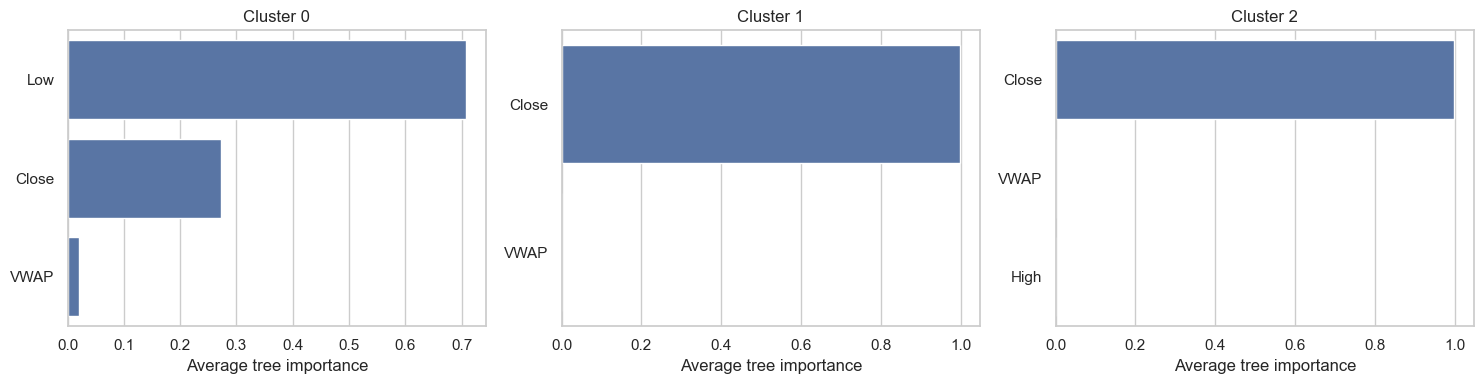

In [12]:
clusters = sorted(tree_importance["cluster"].unique())
fig, axes = plt.subplots(1, len(clusters), figsize=(15, 4))

if len(clusters) == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, clusters):
    top_features = tree_importance[
        (tree_importance["cluster"] == cluster_id)
        & (tree_importance["importance"] > 0.0001)
    ].head(6)

    sns.barplot(data=top_features, y="feature", x="importance", ax=ax)
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Average tree importance")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


<a id="step-8-shap-pdp-ice-and-final-feature-selection"></a>

## Step 8: SHAP, PDP, ICE, and final feature selection

The tree importance tells us which features are useful for prediction. SHAP checks the average contribution of the features.
PDP and ICE plots then show how the strongest selected features affect predictions.

The table after this section is the actual include / neglect decision for Ridge Regression.


In [13]:
best_depth_by_cluster = (
    tree_scores.sort_values("validation_MAE")
    .groupby("cluster")["max_depth"]
    .first()
    .to_dict()
)

tree_models = {}

for cluster_id in sorted(train_df["asset_cluster"].unique()):
    depth = int(best_depth_by_cluster.get(cluster_id, 4))
    cluster_train = train_df[train_df["asset_cluster"] == cluster_id]

    tree = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_leaf=100,
        random_state=SEED,
    )
    tree.fit(cluster_train[candidate_features], cluster_train["future_price"])
    tree_models[cluster_id] = tree

try:
    import shap
    shap_available = True
except Exception as error:
    shap_available = False
    print("SHAP could not be imported. Tree importance will be used instead.")
    print(error)

shap_rows = []

if shap_available:
    for cluster_id, tree in tree_models.items():
        cluster_sample = train_df[train_df["asset_cluster"] == cluster_id].sample(
            min(300, len(train_df[train_df["asset_cluster"] == cluster_id])),
            random_state=SEED,
        )
        X_shap = cluster_sample[candidate_features]

        explainer = shap.TreeExplainer(tree)
        shap_values = explainer.shap_values(X_shap)
        mean_abs_shap = np.abs(shap_values).mean(axis=0)

        for feature, value in zip(candidate_features, mean_abs_shap):
            shap_rows.append(
                {
                    "cluster": cluster_id,
                    "feature": feature,
                    "mean_abs_shap": value,
                }
            )

shap_importance = pd.DataFrame(shap_rows)

if len(shap_importance) > 0:
    display(shap_importance.sort_values(["cluster", "mean_abs_shap"], ascending=[True, False]).groupby("cluster").head(8))


,cluster,feature,mean_abs_shap
4,0,Low,70.291951
5,0,Close,33.159115
7,0,VWAP,11.265479
0,0,asset_cluster,0.000000
1,0,Count,0.000000
2,0,Open,0.000000
3,0,High,0.000000
6,0,Volume,0.000000
31,1,Close,5.194332
33,1,VWAP,0.038549


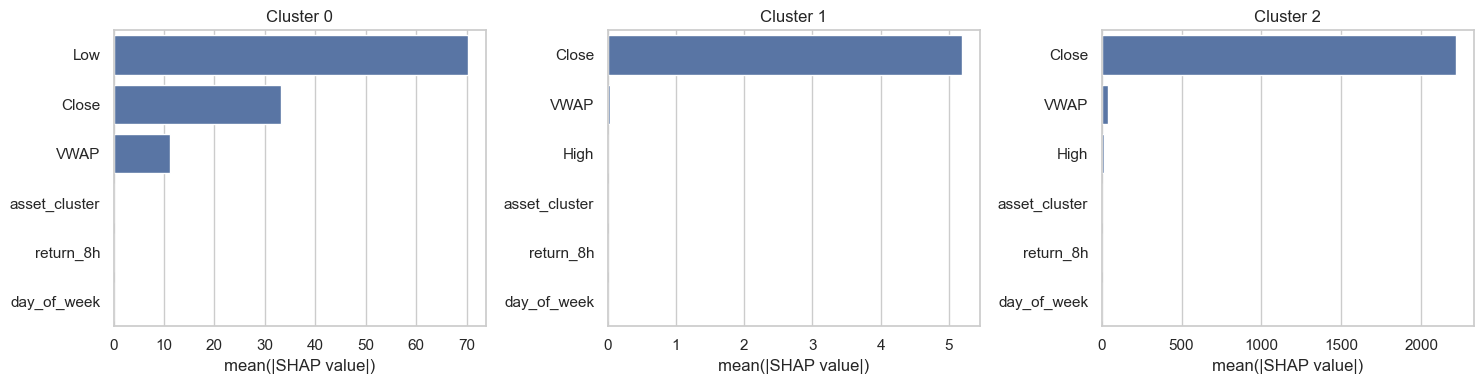

In [14]:
if len(shap_importance) > 0:
    fig, axes = plt.subplots(1, len(clusters), figsize=(15, 4))

    if len(clusters) == 1:
        axes = [axes]

    for ax, cluster_id in zip(axes, clusters):
        top_shap = (
            shap_importance[shap_importance["cluster"] == cluster_id]
            .sort_values("mean_abs_shap", ascending=False)
            .head(6)
        )
        sns.barplot(data=top_shap, y="feature", x="mean_abs_shap", ax=ax)
        ax.set_title(f"Cluster {cluster_id}")
        ax.set_xlabel("mean(|SHAP value|)")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()


In [15]:
top_n_features = 6
features_not_for_ridge = ["asset_cluster", "Weight"]

feature_decision = tree_importance.copy()
feature_decision["tree_rank"] = feature_decision.groupby("cluster")["importance"].rank(
    method="first", ascending=False
)

if len(shap_importance) > 0:
    feature_decision = feature_decision.merge(shap_importance, on=["cluster", "feature"], how="left")
    feature_decision["shap_rank"] = feature_decision.groupby("cluster")["mean_abs_shap"].rank(
        method="first", ascending=False
    )
else:
    feature_decision["mean_abs_shap"] = np.nan
    feature_decision["shap_rank"] = np.nan

feature_decision["rank_for_selection"] = feature_decision["shap_rank"].fillna(
    feature_decision["tree_rank"]
)
feature_decision["combined_rank"] = feature_decision["tree_rank"] + feature_decision["rank_for_selection"]
feature_decision["decision"] = "do not include in Ridge"
feature_decision["reason"] = "low importance compared with selected features"
feature_decision.loc[
    feature_decision["feature"].isin(features_not_for_ridge),
    "reason",
] = "used for clustering/context, not inside the final one-asset Ridge model"

ridge_features_by_cluster = {}
ridge_neglected_by_cluster = {}

for cluster_id in sorted(feature_decision["cluster"].unique()):
    eligible = feature_decision[
        (feature_decision["cluster"] == cluster_id)
        & (~feature_decision["feature"].isin(features_not_for_ridge))
        & ((feature_decision["importance"] > 0.0001) | (feature_decision["mean_abs_shap"] > 0.0001))
    ].sort_values("combined_rank")

    if len(eligible) == 0:
        eligible = feature_decision[
            (feature_decision["cluster"] == cluster_id)
            & (~feature_decision["feature"].isin(features_not_for_ridge))
        ].sort_values("combined_rank")

    selected = eligible.head(top_n_features)["feature"].tolist()
    ridge_features_by_cluster[cluster_id] = selected

    include_mask = (
        (feature_decision["cluster"] == cluster_id)
        & (feature_decision["feature"].isin(selected))
    )
    feature_decision.loc[include_mask, "decision"] = "include in Ridge"
    feature_decision.loc[include_mask, "reason"] = "selected by tree importance and SHAP check"

    ridge_neglected_by_cluster[cluster_id] = feature_decision[
        (feature_decision["cluster"] == cluster_id)
        & (~feature_decision["feature"].isin(selected))
    ]["feature"].tolist()

ridge_feature_summary = pd.DataFrame(
    [
        {
            "cluster": cluster_id,
            "include_in_Ridge": ridge_features_by_cluster[cluster_id],
            "neglect": ridge_neglected_by_cluster[cluster_id],
        }
        for cluster_id in sorted(ridge_features_by_cluster)
    ]
)

compact_decision_table = (
    feature_decision[
        ["cluster", "feature", "importance", "mean_abs_shap", "tree_rank", "shap_rank", "decision", "reason"]
    ]
    .sort_values(["cluster", "decision", "tree_rank"])
)

display(compact_decision_table)
display(ridge_feature_summary)


,cluster,feature,importance,mean_abs_shap,tree_rank,shap_rank,decision,reason
3,0,Count,0.000000,0.000000,4.0,4.0,do not include in Ridge,low importance compared with selected features
4,0,High,0.000000,0.000000,5.0,5.0,do not include in Ridge,low importance compared with selected features
5,0,Open,0.000000,0.000000,6.0,6.0,do not include in Ridge,low importance compared with selected features
6,0,Volume,0.000000,0.000000,7.0,7.0,do not include in Ridge,low importance compared with selected features
7,0,Weight,0.000000,0.000000,8.0,8.0,do not include in Ridge,"used for clustering/context, not inside the final one-asset Ridge model"
8,0,asset_cluster,0.000000,0.000000,9.0,9.0,do not include in Ridge,"used for clustering/context, not inside the final one-asset Ridge model"
9,0,bitcoin_return_4h,0.000000,0.000000,10.0,10.0,do not include in Ridge,low importance compared with selected features
10,0,candle_return,0.000000,0.000000,11.0,11.0,do not include in Ridge,low importance compared with selected features
11,0,close_vwap_gap_pct,0.000000,0.000000,12.0,12.0,do not include in Ridge,low importance compared with selected features
12,0,count_log,0.000000,0.000000,13.0,13.0,do not include in Ridge,low importance compared with selected features


,cluster,include_in_Ridge,neglect
0,0,"[Low, Close, VWAP]","[Count, High, Open, Volume, Weight, asset_cluster, bitcoin_return_4h, candle_return, close_vwap_gap_pct, count_log, ..."
1,1,"[Close, VWAP, High]","[Count, Low, Open, Volume, Weight, asset_cluster, bitcoin_return_4h, candle_return, close_vwap_gap_pct, count_log, d..."
2,2,"[Close, VWAP, High]","[Count, Low, Open, Volume, Weight, asset_cluster, bitcoin_return_4h, candle_return, close_vwap_gap_pct, count_log, d..."


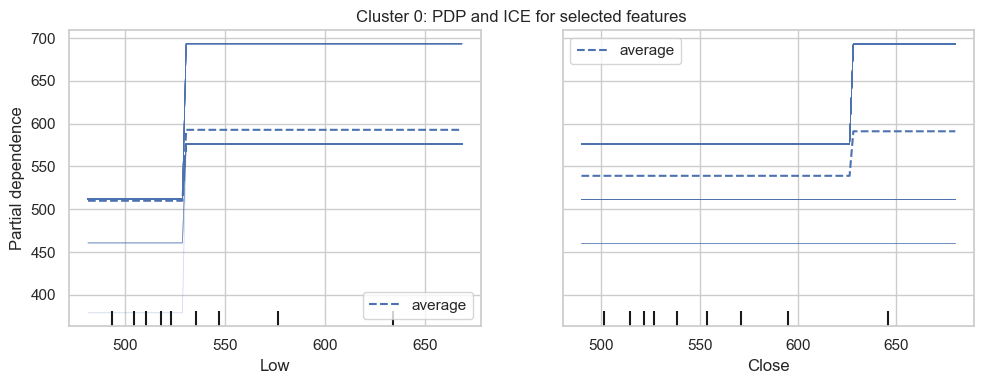

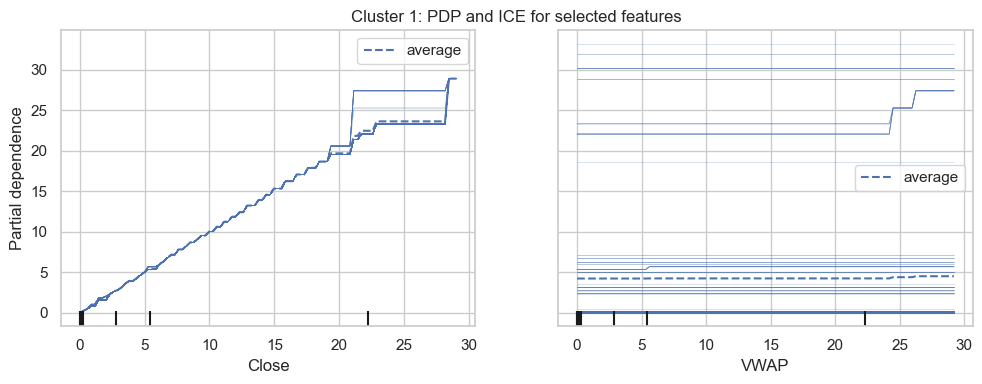

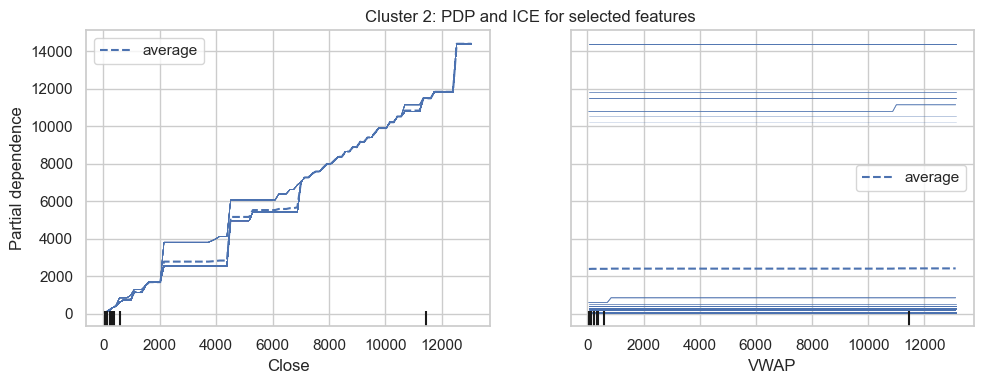

In [16]:
for cluster_id, tree in tree_models.items():
    cluster_val = validation_df[validation_df["asset_cluster"] == cluster_id]
    if len(cluster_val) == 0:
        continue

    features_to_plot = ridge_features_by_cluster[cluster_id][:2]
    X_plot = cluster_val.sample(min(200, len(cluster_val)), random_state=SEED)[candidate_features]

    fig, ax = plt.subplots(figsize=(10, 4))
    PartialDependenceDisplay.from_estimator(
        tree,
        X_plot,
        features=features_to_plot,
        kind="both",
        ax=ax,
    )
    ax.set_title(f"Cluster {cluster_id}: PDP and ICE for selected features")
    plt.tight_layout()
    plt.show()


In [17]:
for cluster_id in sorted(ridge_features_by_cluster):
    print(f"Cluster {cluster_id}")
    print("Include:", ", ".join(ridge_features_by_cluster[cluster_id]))
    print("Neglect:", ", ".join(ridge_neglected_by_cluster[cluster_id]))
    print()


Cluster 0
Include: Low, Close, VWAP
Neglect: Count, High, Open, Volume, Weight, asset_cluster, bitcoin_return_4h, candle_return, close_vwap_gap_pct, count_log, day_of_week, ethereum_return_4h, high_low_range_pct, hour, market_return_4h, month, other_assets_return_4h, return_24h, return_4h, return_8h, rolling_return_mean_24h, rolling_volatility_24h, volume_log

Cluster 1
Include: Close, VWAP, High
Neglect: Count, Low, Open, Volume, Weight, asset_cluster, bitcoin_return_4h, candle_return, close_vwap_gap_pct, count_log, day_of_week, ethereum_return_4h, high_low_range_pct, hour, market_return_4h, month, other_assets_return_4h, return_24h, return_4h, return_8h, rolling_return_mean_24h, rolling_volatility_24h, volume_log

Cluster 2
Include: Close, VWAP, High
Neglect: Count, Low, Open, Volume, Weight, asset_cluster, bitcoin_return_4h, candle_return, close_vwap_gap_pct, count_log, day_of_week, ethereum_return_4h, high_low_range_pct, hour, market_return_4h, month, other_assets_return_4h, return

<a id="step-9-asset-specific-ridge-regression"></a>

## Step 9: Asset-specific Ridge Regression

We now train one Ridge Regression model for each asset. Each asset uses only the features selected for its cluster.
The validation set chooses the L2 penalty (`alpha`). The final test period is used only once for performance evaluation.


In [18]:
ridge_alpha_values = [0.1, 1.0, 10.0, 100.0]

asset_models = {}
model_rows = []
coefficient_rows = []
prediction_frames = []

for asset_name in sorted(train_df["Asset_Name"].unique()):
    asset_train = train_df[train_df["Asset_Name"] == asset_name].copy()
    asset_val = validation_df[validation_df["Asset_Name"] == asset_name].copy()
    asset_test = test_df[test_df["Asset_Name"] == asset_name].copy()

    if len(asset_train) < 50 or len(asset_val) == 0 or len(asset_test) == 0:
        continue

    cluster_id = int(asset_train["asset_cluster"].iloc[0])
    selected_features = ridge_features_by_cluster[cluster_id]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(asset_train[selected_features])
    X_val = scaler.transform(asset_val[selected_features])

    alpha_rows = []
    for alpha in ridge_alpha_values:
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train, asset_train["future_price"])
        val_pred = ridge.predict(X_val)

        alpha_rows.append(
            {
                "alpha": alpha,
                "validation_MAE": mean_absolute_error(asset_val["future_price"], val_pred),
            }
        )

    alpha_results = pd.DataFrame(alpha_rows)
    best_alpha = alpha_results.sort_values("validation_MAE").iloc[0]["alpha"]
    best_validation_mae = alpha_results["validation_MAE"].min()

    train_plus_val = pd.concat([asset_train, asset_val], axis=0)

    scaler = StandardScaler()
    X_train_plus_val = scaler.fit_transform(train_plus_val[selected_features])
    X_test = scaler.transform(asset_test[selected_features])

    ridge = Ridge(alpha=best_alpha)
    ridge.fit(X_train_plus_val, train_plus_val["future_price"])
    test_pred = ridge.predict(X_test)
    train_pred = ridge.predict(X_train_plus_val)

    y_test = asset_test["future_price"]
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)
    test_mape = np.mean(np.abs((y_test - test_pred) / y_test)) * 100

    asset_models[asset_name] = {
        "model": ridge,
        "scaler": scaler,
        "features": selected_features,
        "cluster": cluster_id,
    }

    model_rows.append(
        {
            "Asset_Name": asset_name,
            "cluster": cluster_id,
            "best_alpha": best_alpha,
            "train_validation_MAE": mean_absolute_error(train_plus_val["future_price"], train_pred),
            "validation_MAE_used_for_alpha": best_validation_mae,
            "test_MAE": test_mae,
            "test_RMSE": test_rmse,
            "test_R2": test_r2,
            "test_MAPE_percent": test_mape,
            "features": selected_features,
        }
    )

    for feature, coef in zip(selected_features, ridge.coef_):
        coefficient_rows.append(
            {
                "Asset_Name": asset_name,
                "cluster": cluster_id,
                "best_alpha": best_alpha,
                "intercept": ridge.intercept_,
                "feature": feature,
                "coefficient": coef,
            }
        )

    asset_pred = asset_test[["timestamp", "Asset_Name", "Close", "future_price"]].copy()
    asset_pred["predicted_future_price"] = test_pred
    asset_pred["absolute_error"] = np.abs(asset_pred["future_price"] - asset_pred["predicted_future_price"])
    prediction_frames.append(asset_pred)

model_results = pd.DataFrame(model_rows).sort_values("test_MAPE_percent")
ridge_coefficients = pd.DataFrame(coefficient_rows).sort_values(["Asset_Name", "feature"])
predictions = pd.concat(prediction_frames, ignore_index=True)

display(model_results.round(4))
display(ridge_coefficients.round(6))


,Asset_Name,cluster,best_alpha,train_validation_MAE,validation_MAE_used_for_alpha,test_MAE,test_RMSE,test_R2,test_MAPE_percent,features
1,Bitcoin,2,0.1,82.5364,115.0551,589.4405,844.5427,0.9924,1.3842,"[Close, VWAP, High]"
6,Ethereum,2,0.1,4.5741,4.9901,39.6043,57.8017,0.9948,1.8106,"[Close, VWAP, High]"
11,Monero,2,0.1,1.7841,1.4576,4.9537,7.6654,0.9894,1.9643,"[Close, VWAP, High]"
9,Litecoin,2,1.0,1.1642,0.9062,3.8297,5.8278,0.9883,2.0093,"[Close, VWAP, High]"
2,Bitcoin Cash,2,1.0,8.1741,3.2046,13.3172,22.4998,0.9890,2.0101,"[Close, VWAP, High]"
13,TRON,1,0.1,0.0004,0.0004,0.0015,0.0025,0.9940,2.0103,"[Close, VWAP, High]"
0,Binance Coin,1,0.1,0.2337,0.3308,6.2021,10.1159,0.9963,2.0150,"[Close, VWAP, High]"
3,Cardano,1,0.1,0.0013,0.0017,0.0274,0.0433,0.9958,2.1613,"[Close, VWAP, High]"
5,EOS.IO,1,1.0,0.0880,0.0321,0.1169,0.2208,0.9850,2.2128,"[Close, VWAP, High]"
12,Stellar,1,0.1,0.0022,0.0017,0.0086,0.0133,0.9880,2.2564,"[Close, VWAP, High]"


,Asset_Name,cluster,best_alpha,intercept,feature,coefficient
0,Binance Coin,1,0.1,17.352579,Close,6.517653
2,Binance Coin,1,0.1,17.352579,High,0.278278
1,Binance Coin,1,0.1,17.352579,VWAP,0.809865
3,Bitcoin,2,0.1,8515.865181,Close,2742.548000
5,Bitcoin,2,0.1,8515.865181,High,4.338796
4,Bitcoin,2,0.1,8515.865181,VWAP,539.708442
6,Bitcoin Cash,2,1.0,461.659286,Close,289.618098
8,Bitcoin Cash,2,1.0,461.659286,High,6.910947
7,Bitcoin Cash,2,1.0,461.659286,VWAP,122.921679
9,Cardano,1,0.1,0.085060,Close,0.050929


<a id="step-10-performance-analysis"></a>

## Step 10: Performance analysis

The table and plots below are the final test-set evaluation. MAE and RMSE are in price units, while MAPE makes the errors more comparable across high-price and low-price assets.


In [19]:
print("Average test MAPE:", round(model_results["test_MAPE_percent"].mean(), 2), "%")
print("Median test MAPE:", round(model_results["test_MAPE_percent"].median(), 2), "%")
print("Best asset by MAPE:", model_results.iloc[0]["Asset_Name"])
print("Worst asset by MAPE:", model_results.iloc[-1]["Asset_Name"])

display(
    model_results[
        [
            "Asset_Name",
            "cluster",
            "best_alpha",
            "test_MAE",
            "test_RMSE",
            "test_R2",
            "test_MAPE_percent",
        ]
    ].round(4)
)


Average test MAPE: 2.19 %
Median test MAPE: 2.09 %
Best asset by MAPE: Bitcoin
Worst asset by MAPE: Maker


,Asset_Name,cluster,best_alpha,test_MAE,test_RMSE,test_R2,test_MAPE_percent
1,Bitcoin,2,0.1,589.4405,844.5427,0.9924,1.3842
6,Ethereum,2,0.1,39.6043,57.8017,0.9948,1.8106
11,Monero,2,0.1,4.9537,7.6654,0.9894,1.9643
9,Litecoin,2,1.0,3.8297,5.8278,0.9883,2.0093
2,Bitcoin Cash,2,1.0,13.3172,22.4998,0.9890,2.0101
13,TRON,1,0.1,0.0015,0.0025,0.9940,2.0103
0,Binance Coin,1,0.1,6.2021,10.1159,0.9963,2.0150
3,Cardano,1,0.1,0.0274,0.0433,0.9958,2.1613
5,EOS.IO,1,1.0,0.1169,0.2208,0.9850,2.2128
12,Stellar,1,0.1,0.0086,0.0133,0.9880,2.2564


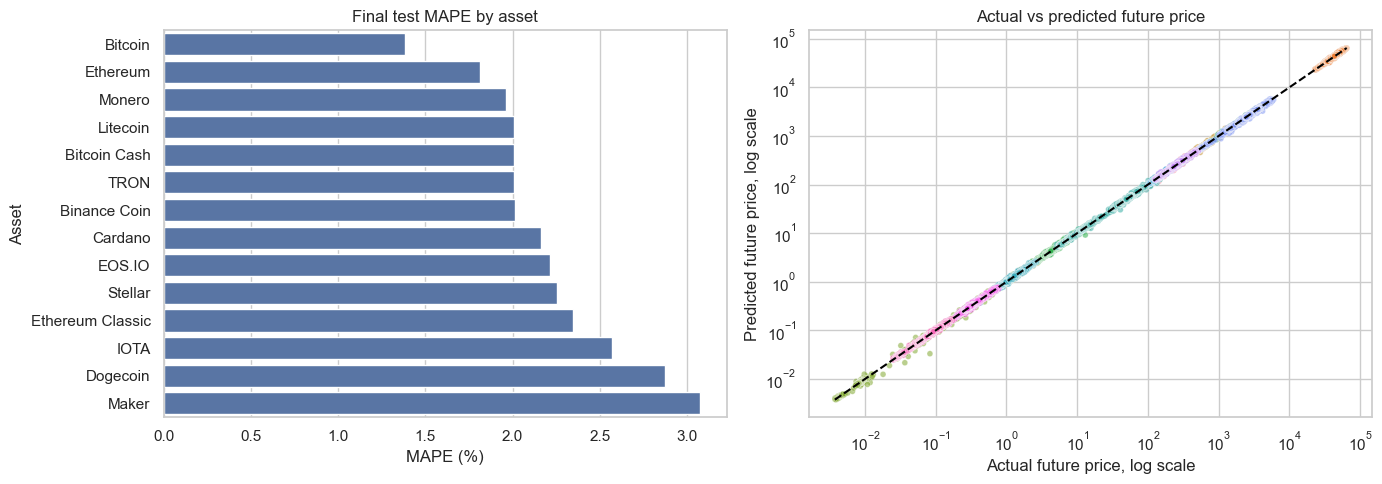

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=model_results,
    y="Asset_Name",
    x="test_MAPE_percent",
    ax=axes[0],
    orient="h",
)
axes[0].set_title("Final test MAPE by asset")
axes[0].set_xlabel("MAPE (%)")
axes[0].set_ylabel("Asset")

sns.scatterplot(
    data=predictions,
    x="future_price",
    y="predicted_future_price",
    hue="Asset_Name",
    alpha=0.55,
    s=18,
    ax=axes[1],
    legend=False,
)

min_price = min(predictions["future_price"].min(), predictions["predicted_future_price"].min())
max_price = max(predictions["future_price"].max(), predictions["predicted_future_price"].max())
axes[1].plot([min_price, max_price], [min_price, max_price], color="black", linestyle="--")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Actual vs predicted future price")
axes[1].set_xlabel("Actual future price, log scale")
axes[1].set_ylabel("Predicted future price, log scale")

plt.tight_layout()
plt.show()


In [21]:
example_asset = model_results.iloc[0]["Asset_Name"]
example_features = asset_models[example_asset]["features"]

example_parameters = (
    test_df[test_df["Asset_Name"] == example_asset]
    .iloc[-1][example_features]
    .to_dict()
)

def predict_future_price_for_asset(asset_name, parameters):
    model_info = asset_models[asset_name]
    row = pd.DataFrame([parameters])
    row_scaled = model_info["scaler"].transform(row[model_info["features"]])
    return model_info["model"].predict(row_scaled)[0]

example_prediction = predict_future_price_for_asset(example_asset, example_parameters)

print("Example asset:", example_asset)
print("Features used:", example_features)
print("Predicted future price:", round(example_prediction, 6))
display(pd.DataFrame([example_parameters]))


Example asset: Bitcoin
Features used: ['Close', 'VWAP', 'High']
Predicted future price: 43849.573322


,Close,VWAP,High
0,43861.215714,43626.770055,44257.99


<a id="step-11-conclusion"></a>

## Step 11: Conclusion

The final model stays intentionally simple. The process is:

1. Cluster assets with KMeans and compare the clustering with alternative methods.
2. Analyze feature importance inside each cluster with decision trees, SHAP, PDP, and ICE.
3. Explicitly decide which features to include and which features to neglect.
4. Train one Ridge Regression model per asset using only the selected features.
5. Evaluate the final models on the untouched test period.

The main result is not that crypto prices can be predicted perfectly. The main result is a transparent process for selecting useful features and building simple asset-specific future price estimates.
